In [11]:
!pip install --upgrade gdown --quiet
import gdown
import os

file_id = '1OLfoj47Cw1nNwNK93tL-2O2lilzmIdNH'
url = f'https://drive.google.com/uc?id={file_id}'
output = '/content/engineered_network_traffic.csv'

if not os.path.exists(output):
    gdown.download(url, output, quiet=False)


!ls -lh /content/*.csv

 85%|████████▌ | 1.00G/1.18G [00:31<00:05, 31.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1OLfoj47Cw1nNwNK93tL-2O2lilzmIdNH
From (redirected): https://drive.google.com/uc?id=1OLfoj47Cw1nNwNK93tL-2O2lilzmIdNH&confirm=t&uuid=a62a305c-45a8-4747-94e6-7511528ecd79
To: /content/engineered_network_traffic.csv
 15%|█▍        | 176M/1.18G [00:02<00:08, 119MB/s] 
100%|██████████| 1.18G/1.18G [00:13<00:00, 86.4MB/s]


-rw------- 1 root root 1.1G Jun  8 06:17 /content/engineered_network_traffic.csv


#  LSTM-Based Anomaly Detection in Network Flow Time Series


## Install & Import Dependencies

In [12]:
%pip install torch scikit-learn pandas matplotlib numpy seaborn imbalanced-learn --quiet

In [13]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
print(f"NumPy    : {np.__version__}")
print(f"Pandas   : {pd.__version__}")

PyTorch  : 2.11.0+cu128
Device   : cuda
NumPy    : 2.0.2
Pandas   : 2.2.2


##  Global Configuration

In [14]:
DATA_PATH = "engineered_network_traffic.csv"
OUT_DIR   = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

CFG = dict(
    seq_len        = 15,
    train_frac     = 0.60,
    hidden_dim     = 128,
    latent_dim     = 16,
    num_layers     = 2,
    dropout        = 0.2,
    epochs         = 60,
    batch_size     = 256,
    lr             = 5e-4,
    weight_decay   = 1e-5,
    threshold_pct  = 95.0,
    patience       = 10,
)

print(f"   Output directory : {OUT_DIR}")
print(f"   Sequence length  : {CFG['seq_len']}")
print(f"   Hidden dim       : {CFG['hidden_dim']}")
print(f"   Latent dim       : {CFG['latent_dim']}")

   Output directory : outputs
   Sequence length  : 15
   Hidden dim       : 128
   Latent dim       : 16


---
##  Data Selection & Feature Engineering

In [15]:
import pandas as pd
import numpy as np
import os

DATA_PATH = "/content/engineered_network_traffic.csv"

if os.path.exists(DATA_PATH):
    df_raw = pd.read_csv(DATA_PATH, on_bad_lines='skip')
    df_raw.columns = df_raw.columns.str.strip()
    for col in df_raw.select_dtypes("object").columns:
        df_raw[col] = df_raw[col].astype(str).str.strip()


In [16]:
if 'df_raw' in globals():
    if "Label" in df_raw.columns:
        df_raw["label"] = (df_raw["Label"].str.upper() != "BENIGN").astype(int)

    num_cols = df_raw.select_dtypes(include=[np.number]).columns
    df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_raw[num_cols] = df_raw[num_cols].fillna(df_raw[num_cols].median())

    df_raw.drop_duplicates(inplace=True)
    print(f" {len(df_raw):,} rows")
else:
    print("Error: 'df_raw' is not defined. Please ensure the dataset is downloaded and the loading cell (Tea2hsL7-3yG) has executed successfully.")

 2,795,112 rows


### Missing Values & Data Quality

In [17]:
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df_raw.isnull().sum()

print("\n" + "=" * 50)
print("INF / NaN VALUES")
print("=" * 50)
num_cols = df_raw.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df_raw[num_cols]).sum()

df_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
df_raw[num_cols] = df_raw[num_cols].fillna(df_raw[num_cols].median())

before = len(df_raw)
df_raw.drop_duplicates(inplace=True)
print(f"\nDuplicates removed: {before - len(df_raw)}")
print(f"Final dataset size : {len(df_raw):,} rows")

MISSING VALUES

INF / NaN VALUES

Duplicates removed: 0
Final dataset size : 2,795,112 rows


###  Feature Selection

In [18]:
EXCLUDE_COLS = {'label', 'Label', 'Timestamp', 'Flow ID', 'Source IP', 'Destination IP', 'Source Port', 'Destination Port', 'Protocol'}
FEAT_COLS = [c for c in df_raw.columns if c not in EXCLUDE_COLS]
print(f" {len(FEAT_COLS)} features.")

 21 features.


### Exploratory Data Analysis (EDA)

In [19]:
print("Feature Statistics:")
df_raw[FEAT_COLS].describe().round(4)

Feature Statistics:


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Fwd Packets/s,Bwd Packets/s,Min Packet Length,...,Packet Length Mean,Packet Length Std,Flow Duration_rmean,Flow Duration_rstd,Total Fwd Packets_rmean,Total Fwd Packets_rstd,Total Backward Packets_rmean,Total Backward Packets_rstd,Total Length of Fwd Packets_rmean,Total Length of Fwd Packets_rstd
count,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,...,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06,2.795112e+06
mean,1.248000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.126000e-01,3.444000e-01,2.060000e-02,3.500000e-03,1.150000e-02,...,5.220000e-02,6.310000e-02,1.248000e-01,1.074000e-01,0.000000e+00,1.000000e-04,0.000000e+00,1.000000e-04,0.000000e+00,1.000000e-04
std,2.819000e-01,3.400000e-03,3.400000e-03,8.000000e-04,3.500000e-03,1.120000e-02,4.320000e-02,8.120000e-02,1.920000e-02,1.750000e-02,...,9.190000e-02,1.342000e-01,2.213000e-01,1.494000e-01,1.100000e-03,3.400000e-03,1.100000e-03,3.400000e-03,3.000000e-04,8.000000e-04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.119000e-01,3.333000e-01,0.000000e+00,0.000000e+00,0.000000e+00,...,1.800000e-03,0.000000e+00,3.000000e-04,3.000000e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.000000e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.119000e-01,3.333000e-01,0.000000e+00,0.000000e+00,1.400000e-03,...,1.740000e-02,5.700000e-03,1.670000e-02,1.580000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.080000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.120000e-01,3.371000e-01,3.900000e-03,3.400000e-03,2.490000e-02,...,3.660000e-02,3.980000e-02,1.188000e-01,2.134000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,9.951000e-01,5.269000e-01,1.006000e-01,3.162000e-01,1.008000e-01,3.162000e-01,1.002000e-01,3.162000e-01


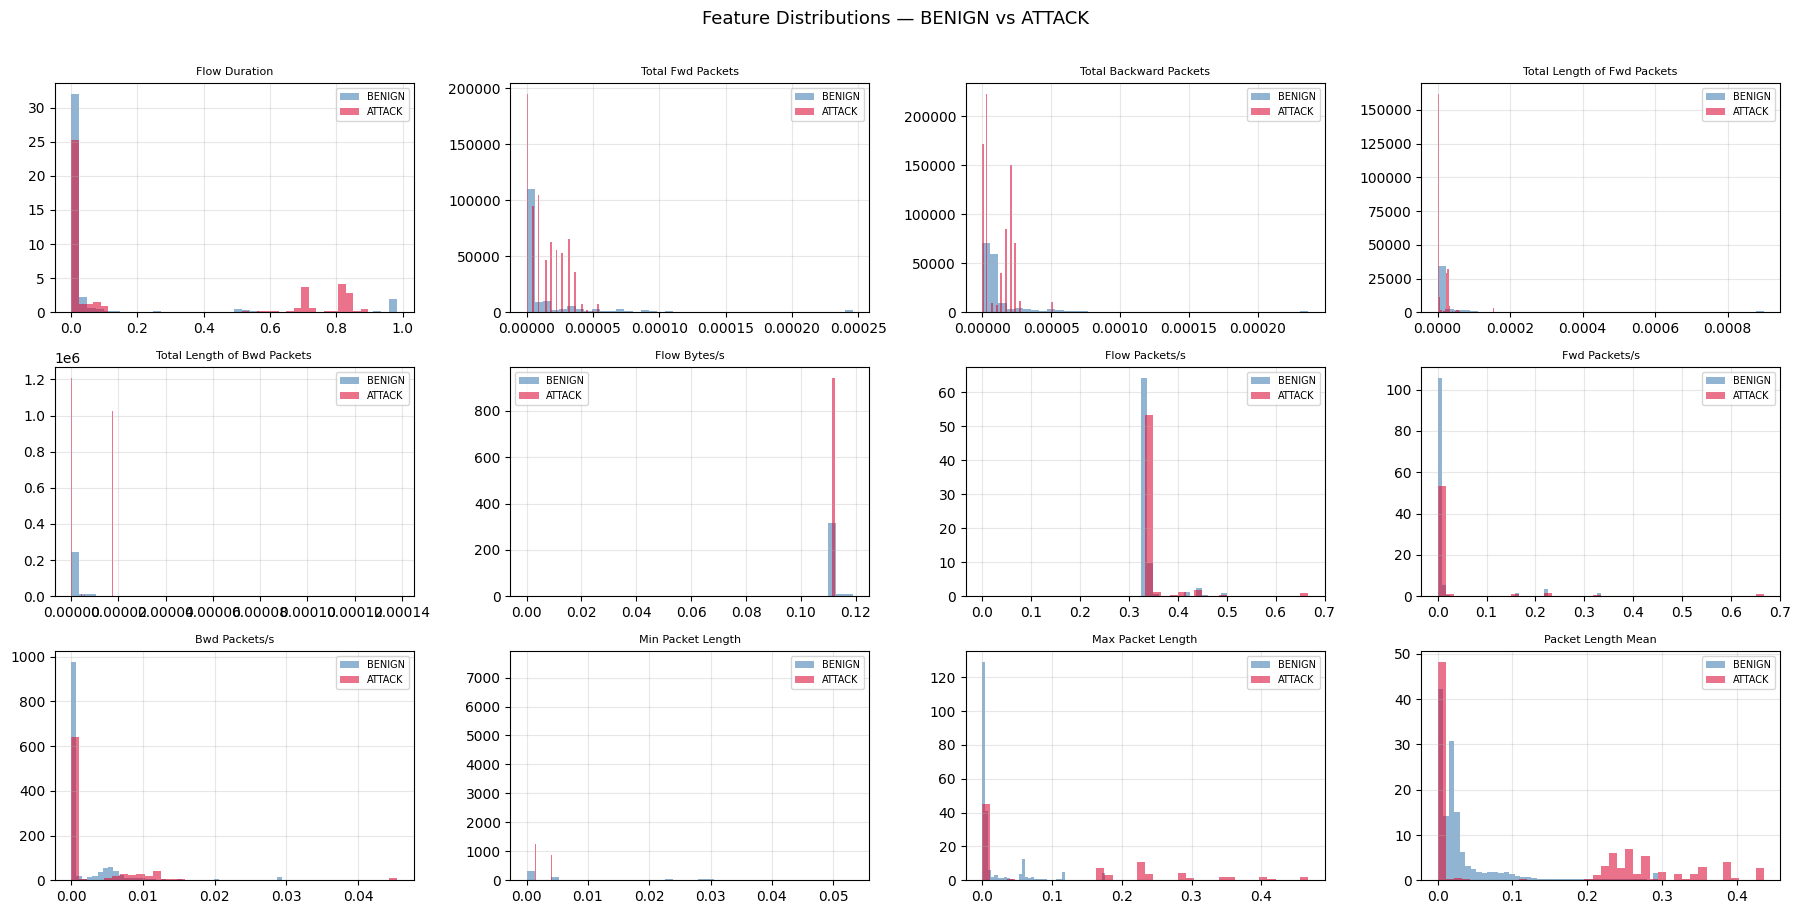

In [20]:
plot_cols = FEAT_COLS[:12]
n_cols = 4
n_rows = (len(plot_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

benign  = df_raw[df_raw["label"] == 0]
attacks = df_raw[df_raw["label"] == 1]

for i, col in enumerate(plot_cols):
    ax = axes[i]
    ax.hist(benign[col].clip(upper=benign[col].quantile(0.99)),
            bins=40, alpha=0.6, color="steelblue", label="BENIGN", density=True)
    if len(attacks) > 0:
        ax.hist(attacks[col].clip(upper=attacks[col].quantile(0.99)),
                bins=40, alpha=0.6, color="crimson", label="ATTACK", density=True)
    ax.set_title(col, fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions — BENIGN vs ATTACK", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()


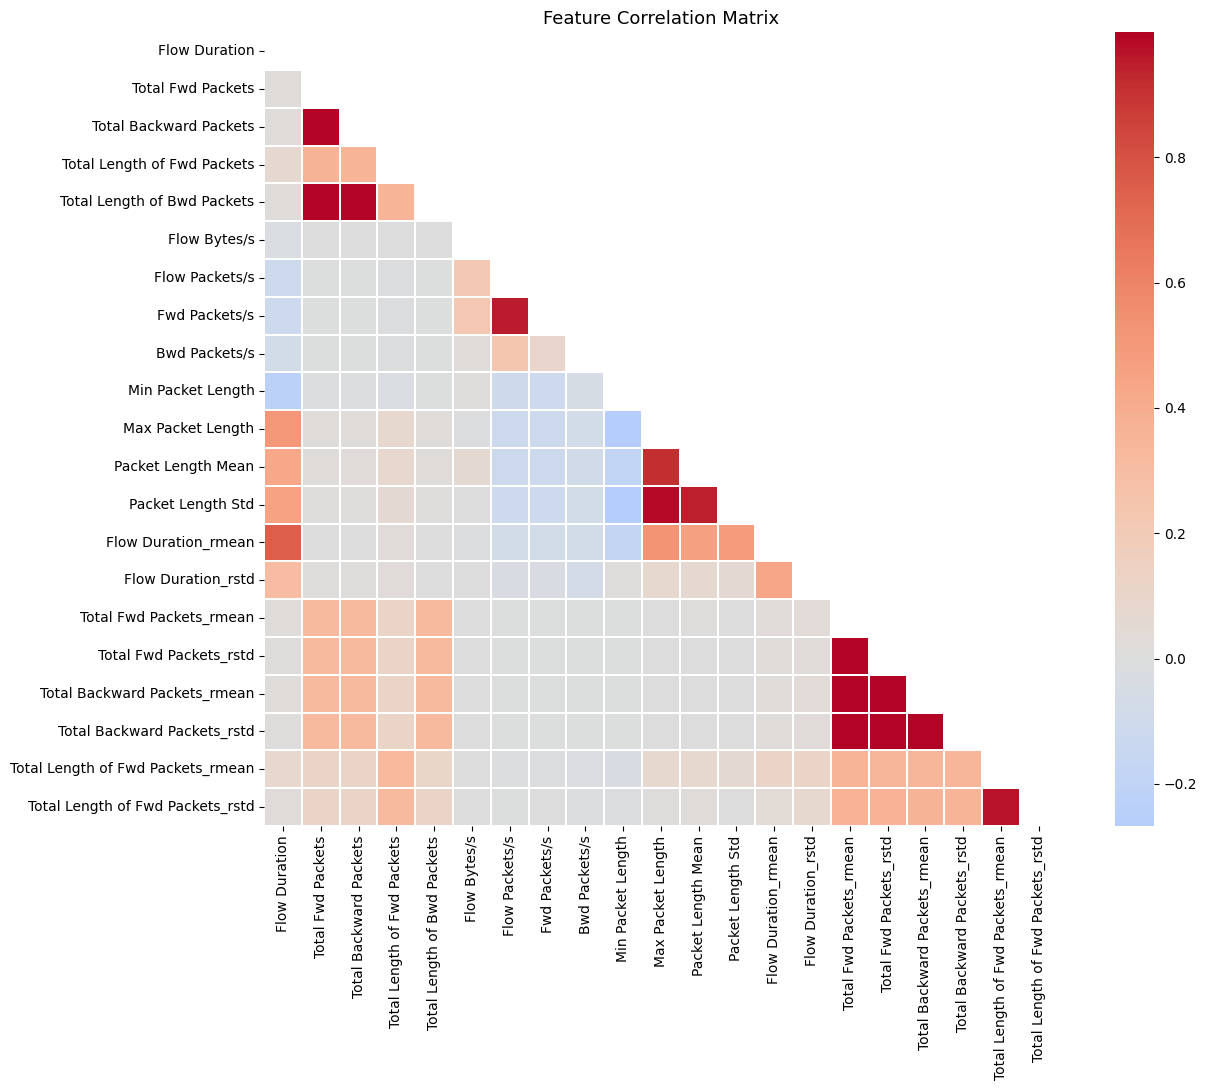

In [21]:
corr = df_raw[FEAT_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            square=True, linewidths=0.3, ax=ax,
            annot=len(FEAT_COLS) <= 15, fmt=".2f", annot_kws={"size": 7})
ax.set_title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

### Time-Series Feature Engineering

In [22]:
def engineer_features(df, feat_cols, window=5):
    df_eng = df[feat_cols + ['label']].copy()
    core_cols = [c for c in feat_cols if '_rmean' not in c and '_rstd' not in c]
    for col in core_cols[:4]:
        df_eng[f'{col}_rmean'] = df_eng[col].rolling(window, min_periods=1).mean()
        df_eng[f'{col}_rstd']  = df_eng[col].rolling(window, min_periods=1).std().fillna(0)
    return df_eng

df_feat = engineer_features(df_raw, FEAT_COLS)
FEAT_COLS_ENG = [c for c in df_feat.columns if c != 'label']


In [23]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
X = df_feat[FEAT_COLS_ENG]
y = df_feat['label']
train_idx = int(0.6 * len(df_feat))
val_idx = int(0.8 * len(df_feat))
X_train_orig, y_train_orig = X.iloc[:train_idx], y.iloc[:train_idx]
X_val, y_val = X.iloc[train_idx:val_idx], y.iloc[train_idx:val_idx]
X_test, y_test = X.iloc[val_idx:], y.iloc[val_idx:]

smote = SMOTE(sampling_strategy=0.25, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_orig, y_train_orig)

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=12, min_samples_leaf=100,
    class_weight='balanced_subsample', random_state=42, n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=12,
                       min_samples_leaf=100, n_jobs=-1, random_state=42)

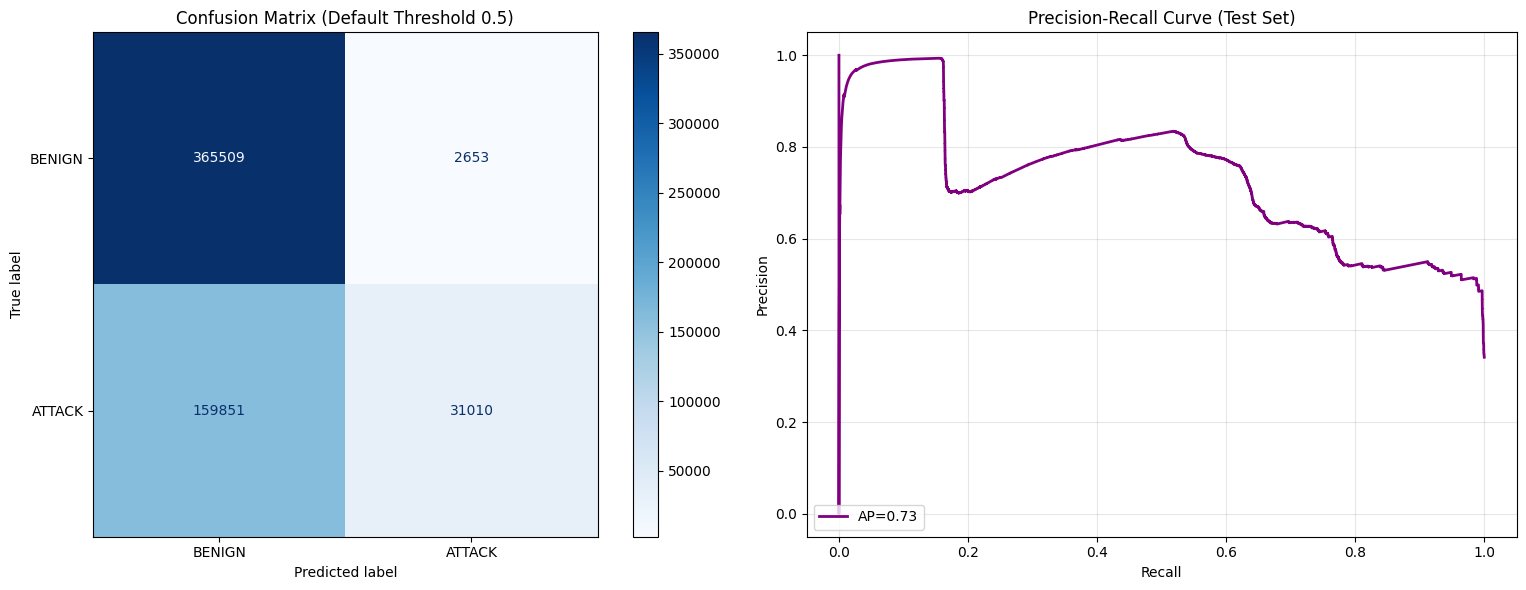

--- Threshold Optimization ---
To reach ~70.0% Recall, use Threshold: 0.0146
Expected Precision at this threshold: 0.6355


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
y_probs_test = rf_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_probs_test >= 0.5).astype(int)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['BENIGN', 'ATTACK'],
    cmap='Blues', ax=ax[0]
)
ax[0].set_title("Confusion Matrix (Default Threshold 0.5)")
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_test)
aps = average_precision_score(y_test, y_probs_test)
ax[1].plot(recall, precision, color='purple', lw=2, label=f'AP={aps:.2f}')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve (Test Set)')
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
target_recall = 0.70
valid_indices = np.where(recall >= target_recall)[0]
if len(valid_indices) > 0:
    idx = valid_indices[-1]
    if idx < len(thresholds):
        opt_threshold = thresholds[idx]
        print(f"--- Threshold Optimization ---")
        print(f"To reach ~{target_recall*100}% Recall, use Threshold: {opt_threshold:.4f}")
        print(f"Expected Precision at this threshold: {precision[idx]:.4f}")
else:
    print("Could not find a threshold meeting the target recall.")

Using Updated Optimized Threshold: 0.0146


,Accuracy,Precision,Recall,F1-Score
Dataset,,,,
Training,0.8120,0.4553,1.0000,0.6257
Validation,0.8020,0.4092,0.9997,0.5807
Test,0.7597,0.6346,0.6982,0.6649


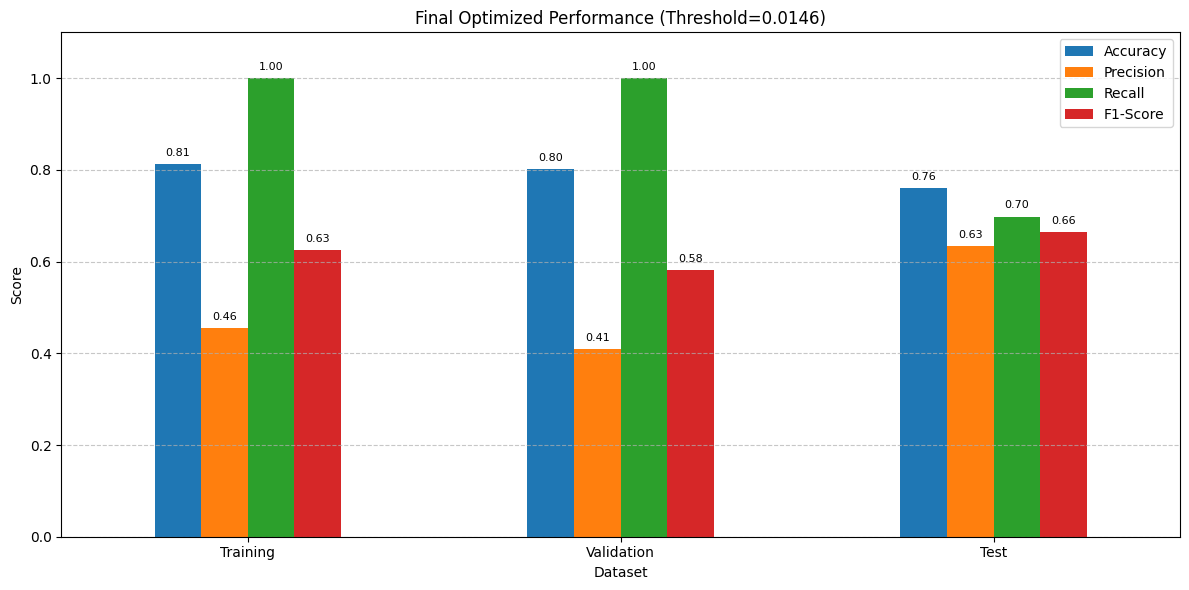

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

best_threshold = 0.0146
print(f"Using Updated Optimized Threshold: {best_threshold:.4f}")

def get_metrics(X_set, y_true, name):
    probs = rf_model.predict_proba(X_set)[:, 1]
    preds = (probs >= best_threshold).astype(int)
    return {
        'Dataset': name,
        'Accuracy': accuracy_score(y_true, preds),
        'Precision': precision_score(y_true, preds),
        'Recall': recall_score(y_true, preds),
        'F1-Score': f1_score(y_true, preds)
    }
final_results = [
    get_metrics(X_train_orig, y_train_orig, 'Training'),
    get_metrics(X_val, y_val, 'Validation'),
    get_metrics(X_test, y_test, 'Test')
]
df_performance = pd.DataFrame(final_results).set_index('Dataset')
display(df_performance.round(4))
ax = df_performance.plot(kind='bar', figsize=(12, 6), rot=0, ylim=(0, 1.1))
plt.title(f"Final Optimized Performance (Threshold={best_threshold:.4f})")
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()